In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('spam.csv', encoding='latin1')
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5411,ham,I ask if u meeting da ge tmr nite...,NaN,NaN,NaN
1673,spam,Monthly password for wap. mobsi.com is 391784....,NaN,NaN,NaN
3687,ham,I'll meet you in the lobby,NaN,NaN,NaN
3678,ham,Stupid.its not possible,NaN,NaN,NaN
2868,ham,"House-Maid is the murderer, coz the man was mu...",NaN,NaN,NaN
180,ham,You lifted my hopes with the offer of money. I...,NaN,NaN,NaN
3250,ham,"IÛ÷ll leave around four, ok?",NaN,NaN,NaN
3068,ham,Ay wana meet on sat?Ì_ wkg on sat?,NaN,NaN,NaN
998,ham,Then Ì_ wait 4 me at bus stop aft ur lect lar....,NaN,NaN,NaN
423,spam,URGENT! Your Mobile number has been awarded wi...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

#1. Data Cleaning
#2. EDA (Exploratory Data Analysis)
3. Text Preprocessing
4. Model Building
5. Evaluation
6. Improvement
7. Website
8. Deployment

## 1. DATA CLEANING 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
print(df.columns.tolist())

columns_to_drop = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

df.sample(10)

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,v1,v2
4306,ham,I guess it is useless calling u 4 something im...
357,spam,Ur cash-balance is currently 500 pounds - to m...
3707,spam,Free Top ringtone -sub to weekly ringtone-get ...
1541,ham,Do u konw waht is rael FRIENDSHIP Im gving yuo...
157,ham,"Hello, my love. What are you doing? Did you ge..."
2512,ham,"Hiya , have u been paying money into my accoun..."
3044,ham,"Hello, yeah i've just got out of the bath and ..."
3549,ham,Dad wanted to talk about the apartment so I go...
2434,ham,Uncle boye. I need movies oh. Guide me. Plus y...
3420,spam,Welcome! Please reply with your AGE and GENDER...


In [7]:
#renaming the columns
df.rename(columns={'v1': 'target', 'v2':'Text'}, inplace=True)
df.sample(10)

,target,Text
5159,ham,No but the bluray player can
3329,ham,Send me yetty's number pls.
3217,ham,Don know:)this week i'm going to tirunelvai da.
107,ham,How would my ip address test that considering ...
2574,spam,Your next amazing xxx PICSFREE1 video will be ...
3129,ham,Ok. But i finish at 6.
5202,ham,WOT STUDENT DISCOUNT CAN U GET ON BOOKS?
736,ham,Thanks for looking out for me. I really apprec...
2376,ham,I'm on my way home. Went to change batt 4 my w...
3618,spam,8007 25p 4 Alfie Moon's Children in Need song ...


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [9]:
df['target'] = encoder.fit_transform(df['target'])
#converts all the ham msgs to 0 and spam to 1

In [10]:
 df.head() #shows the first 5 rows of your data

,target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
#checking missing values
df.isnull().sum()

target    0
Text      0
dtype: int64

In [12]:
#check for any duplicates
df.duplicated().sum()

np.int64(403)

In [13]:
#remove duplicates
df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(403)

In [14]:
df.shape

(5572, 2)

## 2. EDA

In [15]:
df['target'].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x24a2f0e8ec0>,
 [Text(-1.0038715425384215, 0.4497131597824666, 'ham'),
  Text(1.0038714746336121, -0.44971331136284726, 'spam')],
 [Text(-0.547566295930048, 0.24529808715407267, '86.59'),
  Text(0.5475662588910611, -0.24529816983428027, '13.41')])

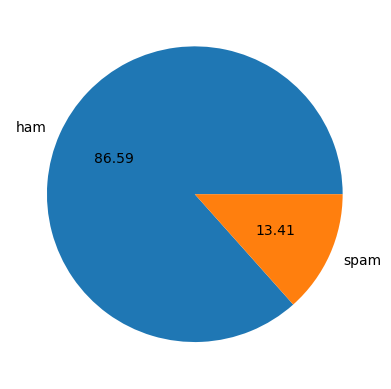

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")

In [17]:
#Data is Imbalanced 

In [18]:
import nltk

In [19]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [20]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
df['num_characters']=df['Text'].apply(len)

In [22]:
df.head()

,target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
import nltk
nltk.download('punkt_tab')  # Try downloading the specific resource mentioned in the error

#  number of words
df['num_words']=df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


df.head()

In [24]:
df.head()

,target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
df['num_sentences']=df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,Text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
#analysis of Ham messages
df[df['target']==0] [['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4825.000000,4825.000000,4825.000000
mean,71.023627,17.276269,1.837720
std,58.016023,13.988585,1.454388
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,92.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
#analysis of spam messages
df[df['target']==1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,747.000000,747.000000,747.000000
mean,138.866131,27.891566,3.021419
std,29.183082,6.867007,1.537580
min,13.000000,2.000000,1.000000
25%,132.500000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [30]:
import seaborn as sns

In [31]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


<Axes: xlabel='num_characters', ylabel='Count'>

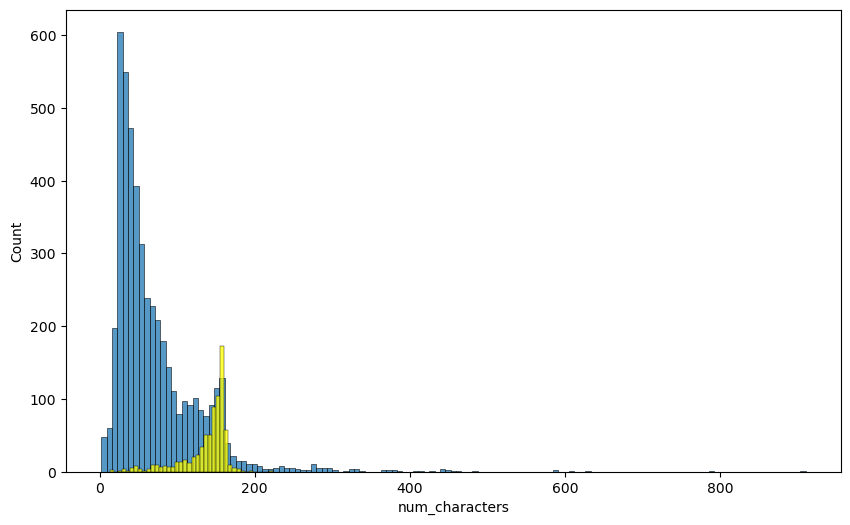

In [32]:
#drawing a histogram for number of characters for Ham and Spam messages
plt.figure(figsize=(10,6))
sns.histplot(df[df['target']==0]['num_characters']) #for Ham
sns.histplot(df[df['target']==1]['num_characters'],color='yellow') #for Spam

<Axes: xlabel='num_words', ylabel='Count'>

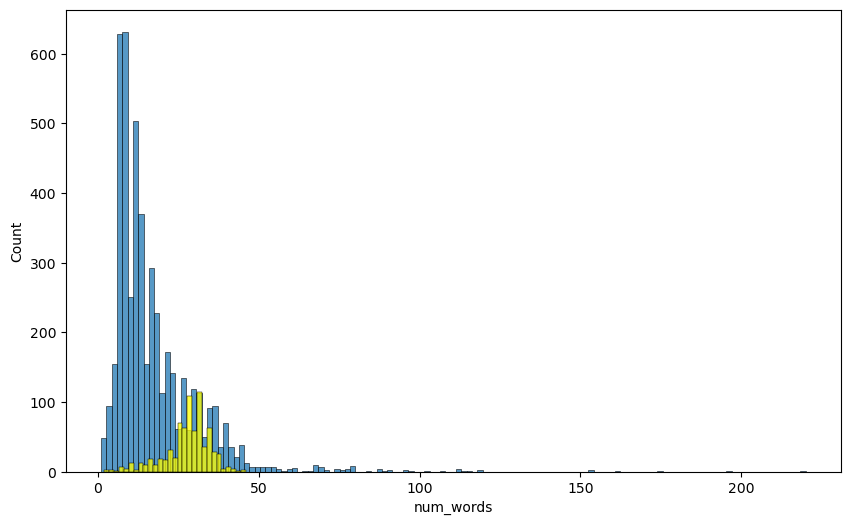

In [33]:
#drawing a histogram for number of words for Ham and Spam messages
plt.figure(figsize=(10,6))
sns.histplot(df[df['target']==0]['num_words']) #for Ham
sns.histplot(df[df['target']==1]['num_words'],color='yellow') #for Spam

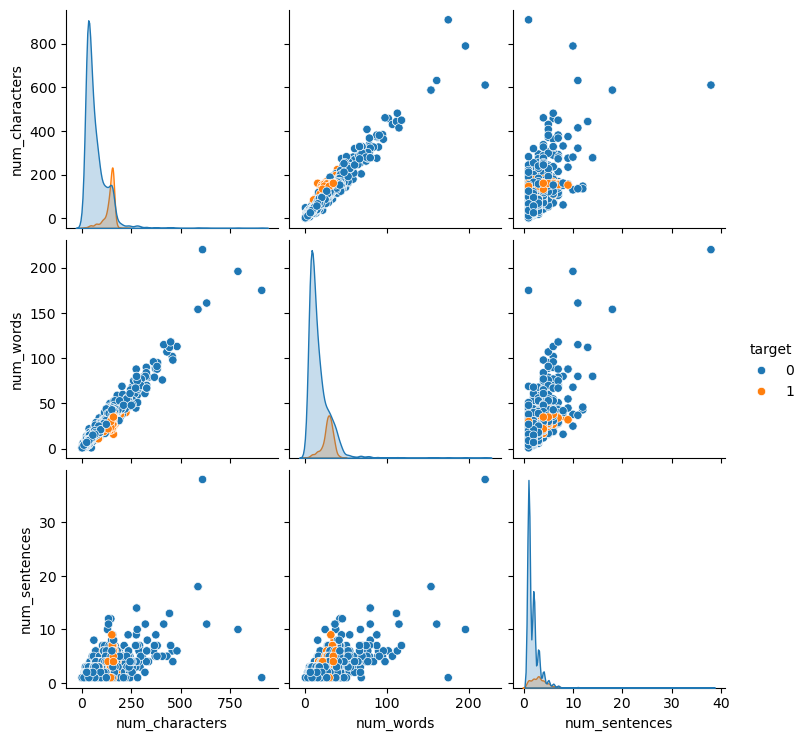

In [34]:
sns.pairplot(df,hue='target')

In [35]:
# First, identify which columns are numerical
numerical_columns = df.select_dtypes(include=['number']).columns

# Then calculate correlation only on numerical columns
correlation_matrix = df[numerical_columns].corr()

# Display the correlation matrix
correlation_matrix

# Alternatively, if you need to convert some text columns to numerical:
# For categorical data, you might use:
# df_encoded = pd.get_dummies(df, columns=['categorical_column_name'])
# df_encoded.corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.387285,0.263221,0.265332
num_characters,0.387285,1.000000,0.966310,0.631881
num_words,0.263221,0.966310,1.000000,0.685165
num_sentences,0.265332,0.631881,0.685165,1.000000


<Axes: >

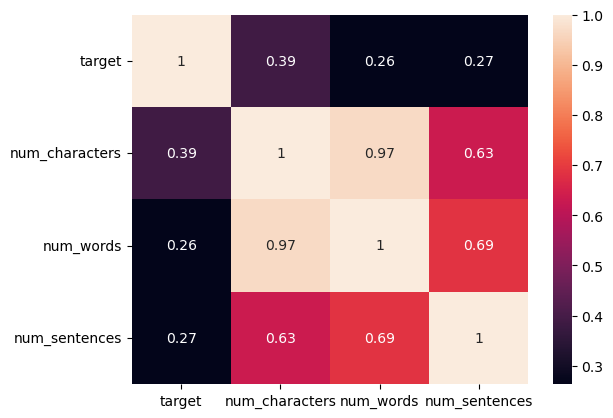

In [36]:
sns.heatmap(df[numerical_columns].corr(),annot=True)

## Data Preprocessing

1. Lower case
2. Tokenization
3. Removing Special Characters
4. Removing stop words and punctuation
5. Stemming

In [37]:
def transform_text(text): #converting into lower case
    text = text.lower()
    text= nltk.word_tokenize(text) #tokenization ; breaking into words

    y =[] #removing special characters
    for i in text:
        if i.isalnum():
            y.append(i)

        text = y[:] #Removing stop words and punctuation
        y.clear()

        for i in text:
            if i not in stopwords.words('english') and i not in string.punctuation:
                y.append(i)

            text = y [:] #stemming
            y.clear()
            for i in text:
                y.append(ps.stem(i))
                
    return " " .join(y)
    

In [49]:
# Method 1: Use the system command with an exclamation mark
!pip install nltk

# After installation, import and download the stopwords
import nltk
nltk.download('stopwords')



Defaulting to user installation because normal site-packages is not writeable


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [43]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
df['Text'] [000]

In [41]:
from nltk.stem.porter import PorterStemmer#for stemming
ps = PorterStemmer()
ps.stem('Lover')

'lover'

In [52]:
# First, define the transform_text function
def transform_text(text):
    # Add your text transformation logic here
    # For example, a simple transformation might be:
    return text.lower()  # Convert text to lowercase
    
# Then apply the function to the DataFrame column
df['transformed_text'] = df['Text'].apply(transform_text)

In [53]:
df.head()

,target,Text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i don't think he goes to usf, he lives aro..."


In [74]:
# First, install the wordcloud package
!pip install wordcloud #highlights the most frequently occurring words

# Then import and use it
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=20, background_color='white')

Defaulting to user installation because normal site-packages is not writeable


In [76]:
# Step 1: Check what columns actually exist in your DataFrame
print("Available columns in DataFrame:")
print(df.columns.tolist())

# Step 2: Check if 'target' column exists and what values it contains
if 'target' in df.columns:
    print("\nUnique values in 'target' column:")
    print(df['target'].unique())
else:
    print("\n'target' column does not exist in this DataFrame")

# Step 3: Display a sample of the DataFrame to see its structure
print("\nSample of DataFrame (first 3 rows):")
print(df.head(3))

# Step 4: After examining the output above, use the correct column names
# Replace 'text_column_name' with the actual column name containing text data
# that you identified from the output above

# Example usage with proper error handling:
try:
    # Identify the column that contains text data from the output above
    text_column = 'text'  # Replace with the actual column name you identified
    
    # Check if the column exists before using it
    if text_column in df.columns and 'target' in df.columns:
        # Generate word cloud only if both columns exist
        text_data = df[df['target'] == 1][text_column].str.cat(sep=" ")
        if len(text_data) > 0:
            wc.generate(text_data)
        else:
            print(f"No text data found for target=1 in column '{text_column}'")
    else:
        print(f"Required columns not found. Please check column names.")
except Exception as e:
    print(f"Error occurred: {e}")

Available columns in DataFrame:
['target', 'Text', 'num_characters', 'num_words', 'num_sentences', 'transformed_text']

Unique values in 'target' column:
[0 1]

Sample of DataFrame (first 3 rows):
   target                                               Text  num_characters  \
0       0  Go until jurong point, crazy.. Available only ...             111   
1       0                      Ok lar... Joking wif u oni...              29   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...             155   

   num_words  num_sentences                                   transformed_text  
0         24              2  go until jurong point, crazy.. available only ...  
1          8              2                      ok lar... joking wif u oni...  
2         37              2  free entry in 2 a wkly comp to win fa cup fina...  
Required columns not found. Please check column names.


In [78]:
spam_wc = wc.generate(df[df['target'] == 1] ['transformed_text'].str.cat(sep=""))

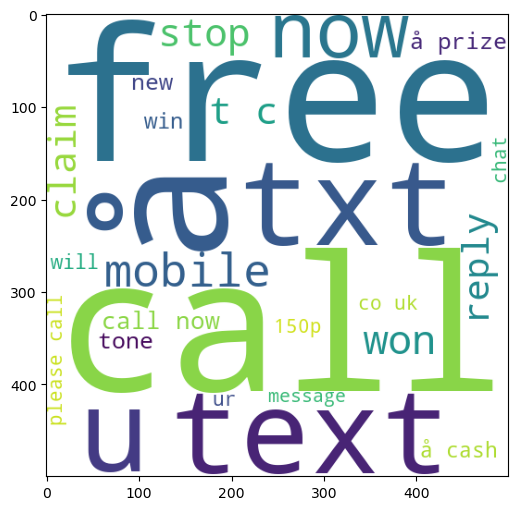

In [80]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [81]:
ham_wc = wc.generate(df[df['target'] == 0] ['transformed_text'].str.cat(sep=""))

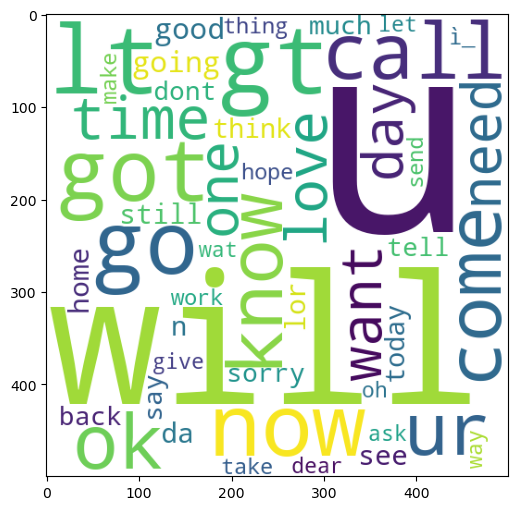

In [82]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [83]:
ham_wc = wc.generate(df[df['target'] == 0] ['transformed_text'].str.cat(sep=""))

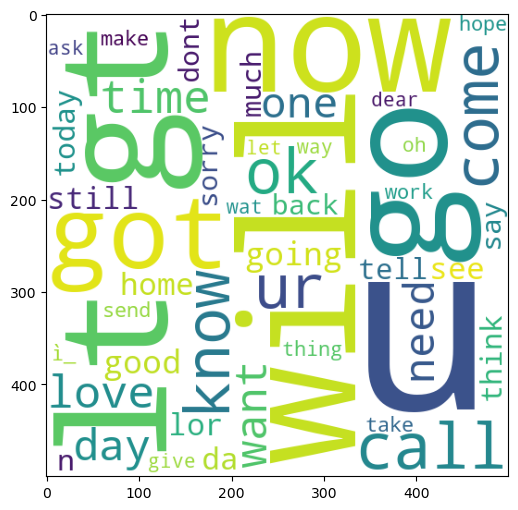

In [84]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [85]:
df.head()

,target,Text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"go until jurong point, crazy.. available only ..."
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"nah i don't think he goes to usf, he lives aro..."


In [90]:
spam_corpus = []
for msg in df[df['target']==1] ['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [93]:
len(spam_corpus)

17817

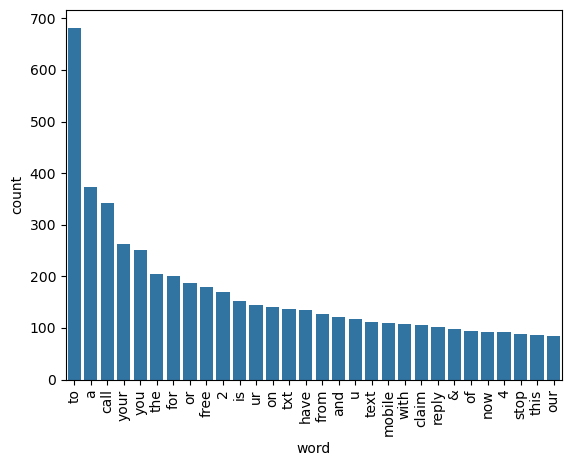

In [99]:
from collections import Counter
#sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0], pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
#from collections import Counter


# Convert Counter results to a DataFrame for easier plotting
most_common_words = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Use named parameters x and y in the barplot function
sns.barplot(x='word', y='count', data=most_common_words) #for bar graph

plt.xticks(rotation='vertical')
plt.show()

In [103]:
ham_corpus = []
for msg in df[df['target']==0] ['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
        

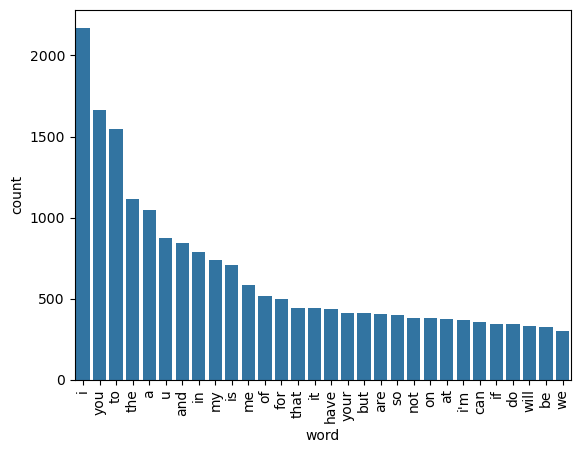

In [104]:
from collections import Counter
#sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0], pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
#from collections import Counter


# Convert Counter results to a DataFrame for easier plotting
most_common_words = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

# Use named parameters x and y in the barplot function
sns.barplot(x='word', y='count', data=most_common_words) #for bar graph

plt.xticks(rotation='vertical') #the names of the bars will become vertical
plt.show()